(60000, 784)
(10000, 784)


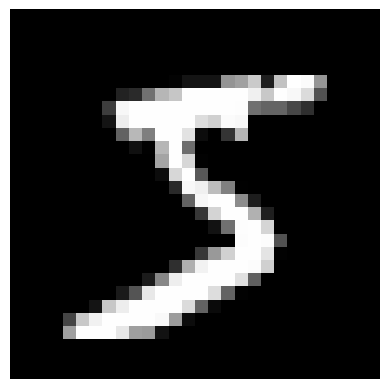

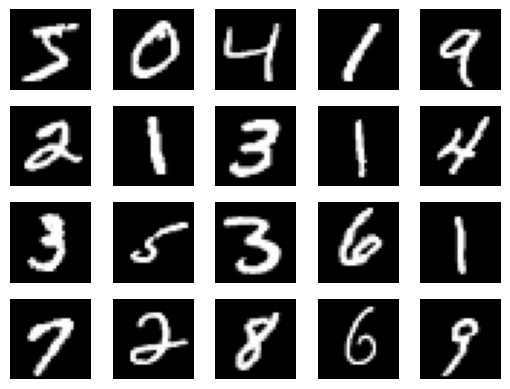

In [ ]:
"""

"""
import gzip
import math
import pickle
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

def get_MNIST_data():
    """
    Loads and preprocesses the MNIST dataset from a gzipped pickle file.

    The MNIST dataset is a collection of handwritten digits widely used for training
    various image processing systems. It contains 70,000 images in total.

    Process:
    1. Opens and reads a compressed pickle file containing MNIST data
    2. Combines training and validation sets into a single training set
    3. Returns separate arrays for training and test data

    Returns:
        tuple: Contains four numpy arrays:
            - train_x (numpy.ndarray): Training images, shape (60000, 784)
                        Each row represents a 28x28 pixel image as a vector of 784 pixels.
            - train_y (numpy.ndarray): Training labels, shape (60000,)
                        Contains digit labels (0-9)
            - test_x (numpy.ndarray): Test images, shape (10000, 784)
                        Same format as train_x
            - test_y (numpy.ndarray): Test labels, shape (10000, )
                        Same format as train_y

    Dependencies:
        - gzip: For reading compressed files
        - pickle: For loading Python objects
        - numpy: For array operations
    """

    with gzip.open('C:/Users/Miguel/OneDrive/Documents/ONIA2026/Datasets/Datasets/mnist.pkl.gz', 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    f.close()
    train_set, valid_set, test_set = data
    train_x, train_y = train_set
    valid_x, valid_y = valid_set
    train_x = np.vstack((train_x, valid_x))
    train_y = np.append(train_y, valid_y)
    test_x, test_y = test_set
    return train_x, train_y, test_x, test_y

def plot_images(X):
    """
    Displays multiple MNIST digit images in a grid layout.

    This function takes a set of MNIST images stored as flattened arrays and displays
    them in a nearly-square grid arrangement. Each image is reshaped from a 1D array
    of 784 pixels into its original 28x28 pixel format and displayed in grayscale.

    Args:
        X (numpy.ndarray): Array of image data. Can be either:
            - 1D array of 784 pixels (single image)
            - 2D array of shape (n, 784) where n is the number of images
    """

    if X.ndim == 1:
        X = np.array([X])
    num_images = X.shape[0]
    num_rows = math.floor(math.sqrt(num_images))
    num_cols = math.ceil(num_images/num_rows)
    for i in range(num_images):
        reshaped_image = X[i,:].reshape(28,28)
        plt.subplot(num_rows, num_cols, i+1)
        plt.imshow(reshaped_image, cmap = cm.Greys_r)
        plt.axis('off')
    plt.show()

if __name__ == '__main__':
    # Load MNIST data:
    train_x, train_y, test_x, test_y = get_MNIST_data()
    print(train_x.shape)
    # Plot the first 20 images of the training set.
    print(test_x.shape)
    plot_images(train_x[0, :])
    plot_images(train_x[0:20, :])


In [8]:
pip install tensorflow


     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     ---------------------------------------- 41.7/41.7 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB 1.9 MB/s eta 0:03:03
   ---------------------------------------- 0.0/350.8 MB 1.9 MB/s eta 0:03:03
   ---------------------------------------- 0.2/350.8 MB 1.0 MB/s eta 0:05:45
   ---------------------------------------- 0.2/350.8 MB 1.2 MB/s eta 0:05:02
   ---------------------------------------- 0.3/350.8 MB 1.1 MB/s eta 0:05:22
   ---------------------------------------- 0.4/350.8 MB 1.6 MB/s eta 0:03:43
   ---------------------------------------- 0.5/350.8 MB 1.4 MB/s eta 0:04:10
   ---------------------------------------- 0.9/350.8 MB 2.3 MB/s eta 0:02:31
   ---------------------------------------- 1.0/350.8 MB 2.4 MB/s eta 0:02:28
   ---------------------------------------- 1.3/350.8 MB 2.8 MB/s eta 0:02:


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Miguel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
train_x = train_x.reshape(-1, 28, 28, 1)
test_x = test_x.reshape(-1, 28, 28, 1)
print(train_x[0].shape)

(28, 28, 1)


In [22]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_x, train_y, epochs=10, 
                    validation_data=(test_x, test_y))


Epoch 1/10


C:\Users\Miguel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9531 - loss: 0.1501 - val_accuracy: 0.9839 - val_loss: 0.0511
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9858 - loss: 0.0461 - val_accuracy: 0.9881 - val_loss: 0.0346
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9909 - val_loss: 0.0286
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9921 - loss: 0.0258 - val_accuracy: 0.9892 - val_loss: 0.0332
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9941 - loss: 0.0198 - val_accuracy: 0.9907 - val_loss: 0.0312
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9944 - loss: 0.0171 - val_accuracy: 0.9915 - val_loss: 0.0263
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9955 - loss: 0.0139 - val_accuracy: 0.9919 - val_loss: 0.0269
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9965 - loss: 0.0111 - val_acc

313/313 - 1s - 2ms/step - accuracy: 0.9916 - loss: 0.0326


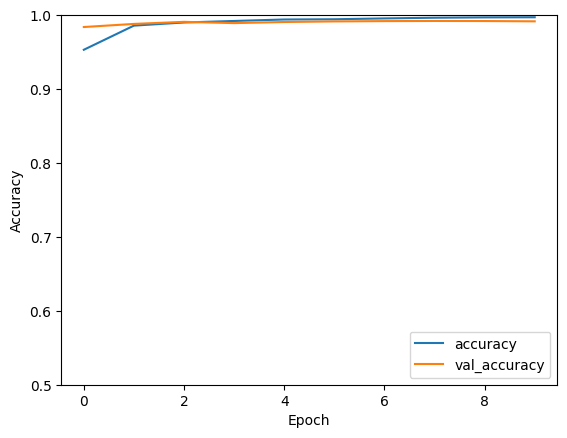

In [24]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_x,  test_y, verbose=2)